# PyTorch MLP driver for O2 gapfill (GPU)
- Standalone companion to `o2_train.ipynb`, focused purely on replacing the sklearn `MLPRegressor` with a native PyTorch MLP trained on GPU.
- Reuses the exact same data pipeline as `o2_train.ipynb` (config, basin/predictor selection, depth subsetting, leak-safe train/test split, decadal K-fold definition) so results are comparable; only the model-training cells differ.
- `o2_train.ipynb` itself is untouched by this notebook.

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os
import warnings
import torch
import torch.nn as nn
from IPython.display import clear_output, display
from sklearn.metrics import r2_score
warnings.filterwarnings('ignore')

In [125]:
usrid = os.environ['USER']
scratch = f'{os.environ["HOME"]}/scratch'
data_root = f'{os.environ["HOME"]}/data/data/ocean'
os.system(f'mkdir -p {scratch}/ML4O2_temp/')
os.system(f'mkdir -p {scratch}/ML4O2_results/')
os.system(f'mkdir -p {scratch}/WOD18_OSDCTD/')
#
# version information - must match the basin/predictor/data-source digits you want;
# the 1st (algorithm) and 6th (hyperparameter-search) digits are not used by this notebook
ver = '2.3.5.4.6.4'
#
# random seed used throughout (train/test split, model init) for reproducibility;
# vary this across runs to generate ensemble members
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)
#
dirout=f'{scratch}/ML4O2_temp/'
dirfin=f'{scratch}/ML4O2_results/'
#
# max depth (meters): subset to shallow samples for fast iteration; set to a large
# value (e.g. 6000) to use the full water column
max_depth = 1000.
#
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
NVIDIA A100-PCIE-40GB


In [126]:
selection = ver.split('.')
basin = ['atlantic','pacific','indian','southern','arctic',\
         'mediterranean','baltic','black','red','persian',\
         'hudson','japan-east','caspian']
#
print(basin[int(selection[2])-1]+' will be mapped')
#
if selection[3] == '1':
    print('EN4 dataset will be used for T/S input. ')
    endyear=2021
    if selection[1]=='1':
        dirinput = f'{data_root}/ML4O2/input_20250708'
elif selection[3] == '2':
    print('ORAS4 dataset will be used for T/S input. ')
    endyear=2018
elif selection[3] == '3':
    print('SODA3.4.2 dataset will be used for T/S input. ')
elif selection[3] == '4':
    print('EN4 (C14) dataset will be used for T/S input. ')
    endyear=2025
    if selection[1]=='1':
        dirinput = f'{data_root}/ML4O2/input_20250822/'
    elif selection[1]=='2':
        dirinput = f'{data_root}/ML4O2/input_20250708/'
    elif selection[1]=='3':
        #dirinput = f'{data_root}/ML4O2/input_202602/'
        dirinput = f'{data_root}/ML4O2/input_202607/'
    Nlev=102
else:
    print('error - incorrect T/S data type')
#
if selection[4] == '1':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, month')
elif selection[4] == '2':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month)')
elif selection[4] == '3':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma')
elif selection[4] == '4':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma, N2')
elif selection[4] == '5':
    print('Predictor variables include T, S, lon, lat, depth (pressure), cos(month), sin(month)')
elif selection[4] == '6':
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
elif selection[4] == '7':
    print('Predictor variables include T, T anom, S, S anom, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
else:
    print('error - incorrect predictor variable type')

arctic will be mapped
EN4 (C14) dataset will be used for T/S input. 
Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)


In [127]:
# Define the input and output folders
dirin = f'{data_root}/WOD_O2_2022-25/'
fosd='_1x1bin_osd_'
os.system(f'mkdir -p {scratch}/WOD18_OSDCTD/')

0

In [128]:
# select analysis period
# do not change the start year from 1965 (this is when Carpenter 1965 established modern Winkler method)
yrs=np.arange(1965,endyear+1,1)

In [129]:
# basin-specific input data loading
bname0=basin[int(selection[2])-1]
#
if selection[3]=='4':
    if selection[4]=='6':
        doa1 = np.load(f'{dirinput}/o20_{bname0}_1x1_{Nlev}lev.npy')
        dta1 = np.load(f'{dirinput}/t0_{bname0}_1x1_{Nlev}lev.npy')
        dsa1 = np.load(f'{dirinput}/s0_{bname0}_1x1_{Nlev}lev.npy')
        xx1 = np.load(f'{dirinput}/lon0_{bname0}_1x1_{Nlev}lev.npy')
        yy1 = np.load(f'{dirinput}/lat0_{bname0}_1x1_{Nlev}lev.npy')
        zz1 = np.load(f'{dirinput}/depth0_{bname0}_1x1_{Nlev}lev.npy')
        tt1 = np.load(f'{dirinput}/time0_{bname0}_1x1_{Nlev}lev.npy')
        tc1 = np.load(f'{dirinput}/month0_{bname0}_1x1_{Nlev}lev.npy')
        GMT1 = np.load(f'{dirinput}/GMT0_{bname0}_1x1_{Nlev}lev.npy')
    elif selection[4]=='7': # reading in anomalies of O2, T and S
        doa1 = np.load(f'{dirinput}/o2a0_{bname0}_1x1_{Nlev}lev.npy')
        dta1 = np.load(f'{dirinput}/ta0_{bname0}_1x1_{Nlev}lev.npy')
        dsa1 = np.load(f'{dirinput}/sa0_{bname0}_1x1_{Nlev}lev.npy')
        doa2 = np.load(f'{dirinput}/o20_{bname0}_1x1_{Nlev}lev.npy')
        dta2 = np.load(f'{dirinput}/t0_{bname0}_1x1_{Nlev}lev.npy')
        dsa2 = np.load(f'{dirinput}/s0_{bname0}_1x1_{Nlev}lev.npy')
        xx1 = np.load(f'{dirinput}/lon0_{bname0}_1x1_{Nlev}lev.npy')
        yy1 = np.load(f'{dirinput}/lat0_{bname0}_1x1_{Nlev}lev.npy')
        zz1 = np.load(f'{dirinput}/depth0_{bname0}_1x1_{Nlev}lev.npy')
        tt1 = np.load(f'{dirinput}/time0_{bname0}_1x1_{Nlev}lev.npy')
        tc1 = np.load(f'{dirinput}/month0_{bname0}_1x1_{Nlev}lev.npy')
        GMT1 = np.load(f'{dirinput}/GMT0_{bname0}_1x1_{Nlev}lev.npy')
else:
    raise NotImplementedError('This notebook currently mirrors only the selection[3]==4 (EN4 C14) data-loading branch used in o2_train.ipynb; port the other branches from there if needed.')

In [130]:
z_mask = np.where(zz1 <= max_depth,True,False)
Nsample_total = np.size(doa1)
Nsample = np.sum(z_mask)
print(Nsample_total, Nsample, Nsample/Nsample_total)

1077886 930920 0.863653484691331


In [131]:
# generate data matrix (kept unnormalized here; normalization is fit on the training split only, see next cell)
if (selection[4] == '6'):
    X = np.array([dsa1, dta1, xx1, yy1, zz1, GMT1, np.cos(2*np.pi*tc1/12), np.sin(2*np.pi*tc1/12)])
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
elif (selection[4] == '7'):
    X = np.array([dsa1, dsa2, dta1, dta2, xx1, yy1, zz1, GMT1, np.cos(2*np.pi*tc1/12), np.sin(2*np.pi*tc1/12)])
    print('Predictor variables include T, T anom, S, S anom, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
else:
    raise NotImplementedError('Port the other selection[4] branches from o2_train.ipynb if needed.')
X = X[:,z_mask].T
y = doa1[z_mask]
N = np.size(y)
print(np.shape(X))

Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)
(930920, 8)


## Train/test split and decadal K-fold
- Identical logic to `o2_train.ipynb`: 11 random years held out as the outer test set, standardization fit on the training partition only (no leakage), then a 5-fold decadal grouping of the training set for hyperparameter search.

In [132]:
# determine which years to hold out as test data
yr_drop = np.random.choice(yrs,11,replace=False)
print(yr_drop)

# group these years together into a single test mask
yr1_full=np.round(tt1[z_mask]/12+1965)
ind=(yr1_full==yr_drop[0])
for n in np.arange(1,11,1):
    tmp=(yr1_full==yr_drop[n])
    ind=(ind==True)|(tmp==True)
ind1 = (ind==False)
print(f'the count of data point (bins) = {yr1_full.size}')
print(f'the count of test data (bins) = {np.sum(ind)}, which is {np.sum(ind)/yr1_full.size*100}%')

# normalize using training-set statistics only (avoids test-set leakage into Xm/Xstd/ym/ystd)
Xm = np.mean(X[ind1,:],axis=0)
Xstd = np.std(X[ind1,:],axis=0)
ym = np.mean(y[ind1])
ystd = np.std(y[ind1])
Xa = (X - Xm)/Xstd
ya = (y-ym)/ystd

X_train = Xa[ind1,:]
X_test = Xa[ind,:]
y_train = ya[ind1]
y_test = ya[ind]
print(f'the count of train data point (bins) = {y_train.size}')

# Decadal Group K-fold
tbnds=[1965,1977,1989,2000,2012,2022]
tt1z = tt1[z_mask]
yr1 = tt1z[ind1]/12+1965
print(f'The total count of data points = {yr1.size}')
for n in range(5):
    K_test=(yr1>=tbnds[n])&(yr1<tbnds[n+1])
    K_train=(K_test==False)
    print(f'Group {n} train size = {np.sum(K_train)}, test size = {np.sum(K_test)}, {np.sum(K_test)/y_train.size*100:.1f}%')

[1991 2000 2025 1993 1976 1967 1999 2024 2005 1987 1969]
the count of data point (bins) = 930920
the count of test data (bins) = 193500, which is 20.78588922786061%
the count of train data point (bins) = 737420
The total count of data points = 737420
Group 0 train size = 519019, test size = 218401, 29.6%
Group 1 train size = 489001, test size = 248419, 33.7%
Group 2 train size = 677617, test size = 59803, 8.1%
Group 3 train size = 675164, test size = 62256, 8.4%
Group 4 train size = 636887, test size = 100533, 13.6%


## EDA
- Distributions of the target and each predictor, and a correlation table, computed on the training split only (`ind1` mask) to avoid any peeking at the outer test set.
- Followed by an OLS multiple linear regression baseline (see below) with partial dependence plots.

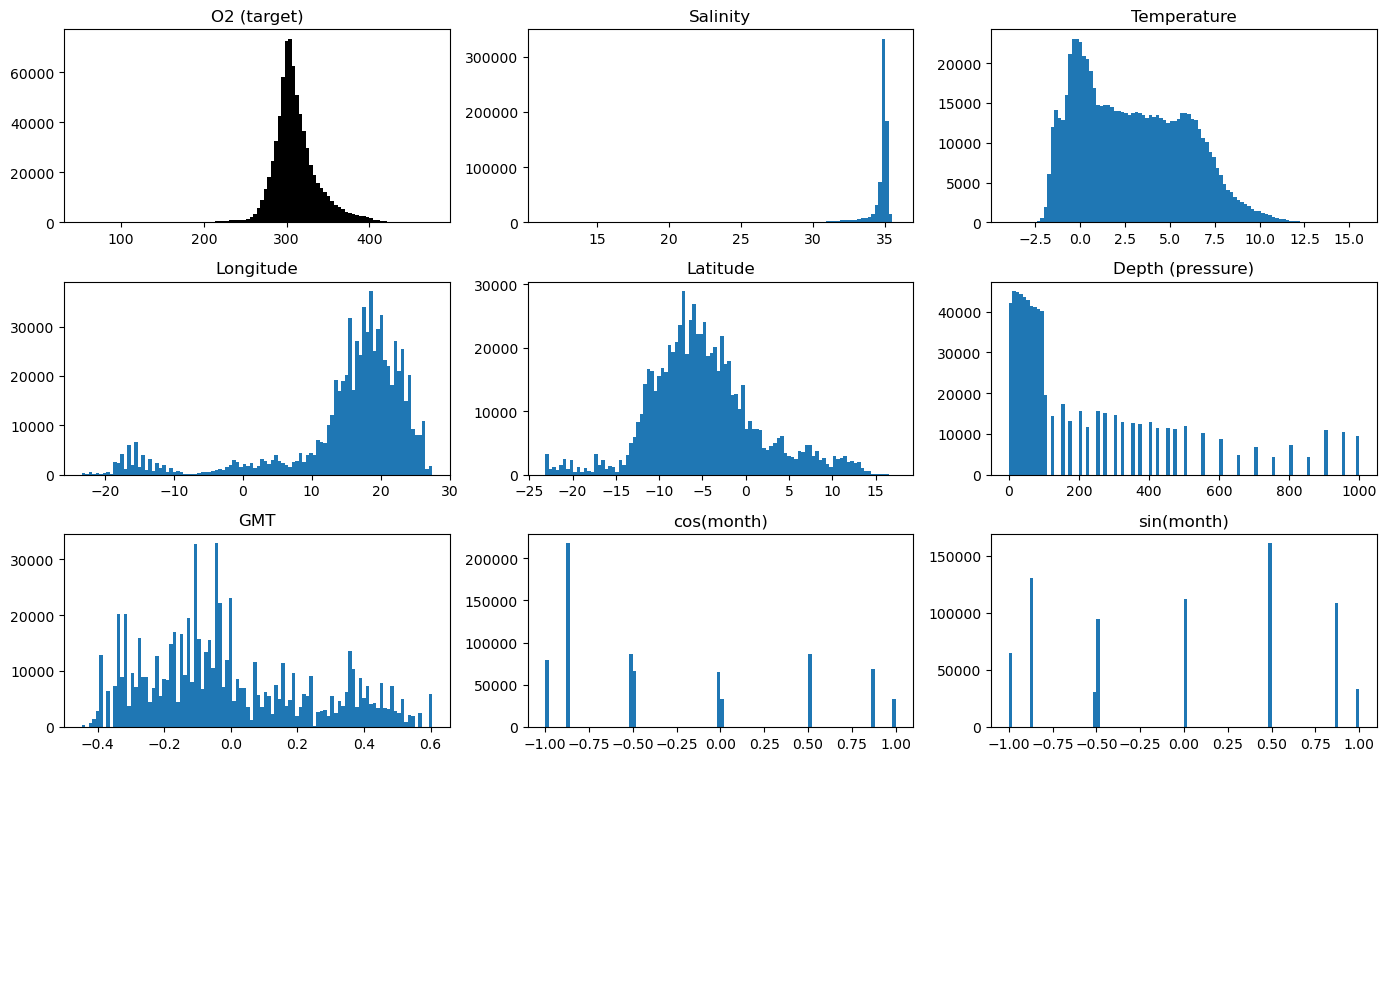

In [133]:
if selection[4]=='6':
    feature_names = ['Salinity', 'Temperature', 'Longitude', 'Latitude', 'Depth (pressure)', \
                  'GMT', 'cos(month)', 'sin(month)']
elif selection[4]=='7':
    feature_names = ['S anom', 'Salinity', 'T anom', 'Temperature', 'Longitude', 'Latitude', 'Depth (pressure)', \
                  'GMT', 'cos(month)', 'sin(month)']
# raw (unstandardized) train-split values, reused by the EDA/linear-regression cells below
X_train_eda = X[ind1, :]
y_train_eda = y[ind1]

fig, axes = plt.subplots(4, 3, figsize=(14, 10))
axes = axes.ravel()
axes[0].hist(y_train_eda, bins=100, color='k')
axes[0].set_title('O2 (target)')
for i, name in enumerate(feature_names):
    axes[i+1].hist(X_train_eda[:, i], bins=100, color='tab:blue')
    axes[i+1].set_title(name)
for ax in axes[len(feature_names)+1:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'Fig_EDA_distributions_v{ver}.pdf')
plt.show()

,Salinity,Temperature,Longitude,Latitude,Depth (pressure),GMT,cos(month),sin(month),O2
Salinity,1.000,0.328,0.606,-0.183,0.195,-0.098,0.103,0.249,-0.414
Temperature,0.328,1.000,0.533,-0.110,-0.378,-0.128,0.027,0.067,-0.452
Longitude,0.606,0.533,1.000,-0.209,0.028,-0.259,0.134,0.316,-0.228
Latitude,-0.183,-0.110,-0.209,1.000,-0.145,-0.056,-0.041,-0.118,0.210
Depth (pressure),0.195,-0.378,0.028,-0.145,1.000,0.145,0.015,0.030,-0.220
GMT,-0.098,-0.128,-0.259,-0.056,0.145,1.000,0.095,-0.130,-0.088
cos(month),0.103,0.027,0.134,-0.041,0.015,0.095,1.000,-0.033,-0.132
sin(month),0.249,0.067,0.316,-0.118,0.030,-0.130,-0.033,1.000,0.094
O2,-0.414,-0.452,-0.228,0.210,-0.220,-0.088,-0.132,0.094,1.000


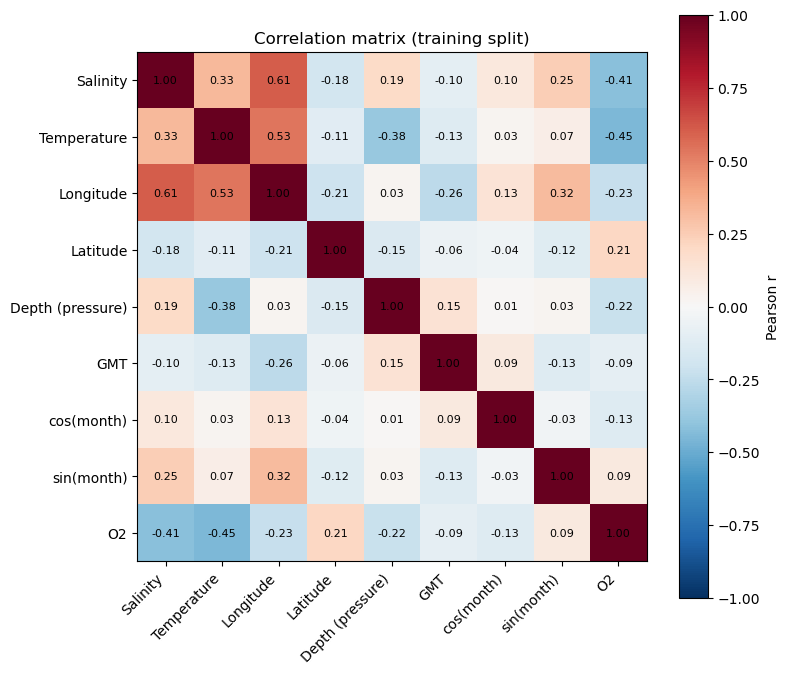

In [134]:
import pandas as pd

df_eda = pd.DataFrame(X_train_eda, columns=feature_names)
df_eda['O2'] = y_train_eda
corr = df_eda.corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Correlation matrix (training split)')
plt.tight_layout()
plt.savefig(f'Fig_EDA_correlation_v{ver}.pdf')
plt.show()

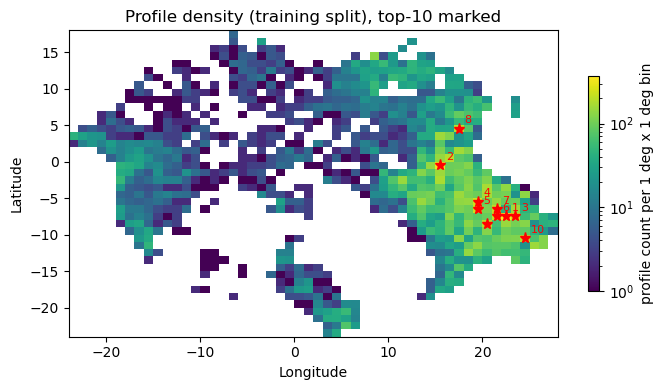

In [135]:
import matplotlib.colors as mcolors

lon_idx = feature_names.index('Longitude')
lat_idx = feature_names.index('Latitude')
lon_train = X_train_eda[:, lon_idx]
lat_train = X_train_eda[:, lat_idx]
tt1_train = tt1z[ind1]

lon_bins = np.arange(np.floor(lon_train.min()), np.ceil(lon_train.max())+1, 1)
lat_bins = np.arange(np.floor(lat_train.min()), np.ceil(lat_train.max())+1, 1)
H, xedges, yedges = np.histogram2d(lon_train, lat_train, bins=[lon_bins, lat_bins])

# profile density: dedupe repeated depth levels at the same lon/lat/year-month (same tt1 value)
# so each profile (cast) is counted once, regardless of how many depth levels it has
profile_keys = np.stack([lon_train, lat_train, tt1_train], axis=1)
_, unique_rows = np.unique(profile_keys, axis=0, return_index=True)
Hp, _, _ = np.histogram2d(lon_train[unique_rows], lat_train[unique_rows], bins=[lon_bins, lat_bins])

# top-10 highest profile-density grid cells; reused below for the map markers and
# in the next cell for the tabulated DataFrame, so both stay in sync
top10_ii, top10_jj = np.unravel_index(np.argsort(Hp.ravel())[::-1][:10], Hp.shape)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.pcolormesh(xedges, yedges, Hp.T, norm=mcolors.LogNorm(vmin=1, vmax=Hp.max()), cmap='viridis')
for rank, (i, j) in enumerate(zip(top10_ii, top10_jj), 1):
    lon_c = 0.5*(xedges[i] + xedges[i+1])
    lat_c = 0.5*(yedges[j] + yedges[j+1])
    ax.plot(lon_c, lat_c, '*', color='r', markersize=8)
    ax.annotate(str(rank), (lon_c, lat_c), textcoords='offset points', xytext=(4, 4), color='r', fontsize=8)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Profile density (training split), top-10 marked')
fig.colorbar(im, ax=ax, label='profile count per 1 deg x 1 deg bin',shrink=.7)
plt.tight_layout()
plt.savefig(f'Fig_EDA_profile_density_v{ver}.pdf')
plt.show()

In [136]:
# top-10 highest profile-density 1deg x 1deg grid cells (training split), kept as a DataFrame
# for later reference (ii/jj computed above, alongside the map markers). profile_count treats
# repeated depth levels at the same lon/lat/year/month as a single profile; count is the raw
# sample count (one entry per depth level), kept alongside for comparison.
top10 = pd.DataFrame({
    'rank': np.arange(1, 11),
    'lon_min': xedges[top10_ii],
    'lon_max': xedges[top10_ii+1],
    'lat_min': yedges[top10_jj],
    'lat_max': yedges[top10_jj+1],
    'profile_count': Hp[top10_ii, top10_jj].astype(int),
    'count': H[top10_ii, top10_jj].astype(int),
})
display(top10)

,rank,lon_min,lon_max,lat_min,lat_max,profile_count,count
0,1,22.0,23.0,-8.0,-7.0,367,13975
1,2,15.0,16.0,-1.0,0.0,325,6452
2,3,23.0,24.0,-8.0,-7.0,249,9989
3,4,19.0,20.0,-6.0,-5.0,232,9638
4,5,19.0,20.0,-7.0,-6.0,226,9454
5,6,21.0,22.0,-8.0,-7.0,207,7919
6,7,21.0,22.0,-7.0,-6.0,205,7740
7,8,17.0,18.0,4.0,5.0,195,4713
8,9,20.0,21.0,-9.0,-8.0,190,7237
9,10,24.0,25.0,-11.0,-10.0,190,7544


In [137]:
# Station identification, by basin. Each basin maps a station name to one or
# more rows of `top10` (selected by rank, 1-indexed) that get combined into a
# single sample mask, mirroring how BATS was originally identified. The mask
# for each station is the union of its constituent grid cells' exact lon/lat
# boxes (not a bounding rectangle), so this is robust even if the cells for a
# station aren't arranged as a simple rectangle.
#
# BATS (Bermuda Atlantic Time-series Study), Atlantic: the two grid cells at
# lon [275,276) (adjacent lat bins [31,32) and [32,33)). Selected by lon
# identity rather than table position, since profile-count ranking (top10's
# sort order) doesn't always put both BATS cells first.
#
# HOT (Hawaii Ocean Time-series) and OSP (Ocean Station Papa), Pacific:
# identified by rank position in `top10` -- HOT = ranks 1-3 combined, OSP =
# rank 5 alone. Ranks are density-based, not fixed lon/lat, so revisit these
# if the input data changes enough to reorder the top10 table.
#
# Basins without a station definition here are skipped (no station-level
# analysis yet); this replaces an earlier version of this cell that used a
# bare `continue` outside of a loop, which is a SyntaxError and crashed this
# cell (and everything downstream that depends on it) for any non-Atlantic
# basin.
if selection[2] == '1':
    station_rows = {'BATS': top10[top10['lon_min'] == 275]}
elif selection[2] == '2':
    station_rows = {
        'HOT': top10[top10['rank'].isin([1, 2, 3])],
        'OSP': top10[top10['rank'] == 5],
    }
else:
    print(f"No station definitions yet for basin '{basin[int(selection[2])-1]}'; skipping station-level analysis.")
    station_rows = {}

lon_all = xx1[z_mask]
lat_all = yy1[z_mask]

def _rows_to_mask(rows):
    mask = np.zeros(lon_all.shape, dtype=bool)
    for _, r in rows.iterrows():
        mask |= (lon_all >= r['lon_min']) & (lon_all < r['lon_max']) & \
                (lat_all >= r['lat_min']) & (lat_all < r['lat_max'])
    return mask

stations = {}
for name, rows in station_rows.items():
    region_mask_all = _rows_to_mask(rows)
    stations[name] = {
        'lon': (rows['lon_min'].min(), rows['lon_max'].max()),
        'lat': (rows['lat_min'].min(), rows['lat_max'].max()),
        'mask_all': region_mask_all,
        'train': region_mask_all[ind1],
        'test': region_mask_all[ind],
    }
    st = stations[name]
    print(f"{name}: lon {st['lon']}, lat {st['lat']}, "
          f"sample count -- train: {np.sum(st['train'])}, test: {np.sum(st['test'])}")

# kept for the BATS case study section below (Atlantic-only), so it doesn't
# need to be rewritten to index into `stations` directly
if 'BATS' in stations:
    region_lon = stations['BATS']['lon']
    region_lat = stations['BATS']['lat']
    region_mask_all = stations['BATS']['mask_all']
    region_train = stations['BATS']['train']
    region_test = stations['BATS']['test']

No station definitions yet for basin 'arctic'; skipping station-level analysis.


In [138]:
# O2 time series at each identified station, for 3 depth bins. Uses the full
# time record (train+test years, i.e. the region mask over the full
# z_mask-filtered arrays) rather than the train-only split, since this is an
# exploratory look at the raw data rather than a leakage-sensitive model fit.
# Multiple depth levels can fall in the same 50m bin, so values are averaged
# per unique timestamp (tt1) to give one point per profile date.
depth_bins = [(0, 50), (100, 150), (300, 350), [600,650]]

depth_z = zz1[z_mask]
o2_z = doa1[z_mask]

for name, st in stations.items():
    fig, axes = plt.subplots(len(depth_bins),1, figsize=(5,6), sharex=True)
    for col, (dmin, dmax) in enumerate(depth_bins):
        cell_mask = st['mask_all'] & (depth_z >= dmin) & (depth_z < dmax)
        ts = pd.DataFrame({'t': tt1z[cell_mask], 'o2': o2_z[cell_mask]}).groupby('t')['o2'].mean().reset_index()
        year = ts['t']/12 + 1965

        ax = axes[col]
        ax.plot(year, ts['o2'], '.-', markersize=3)
        ax.set_title(f'{name}: {dmin}-{dmax} m',loc='left')
        ax.set_xlabel('Year')
        if col == 0:
            ax.set_ylabel('O2')
    plt.tight_layout()
    plt.savefig(f'Fig_station_timeseries_{name}_v{ver}.pdf')
    plt.show()

In [ ]:
# accumulates every model's held-out test-set metrics computed in this
# notebook run, so a single results table can be built per basin (see the
# summary cell at the end) and concatenated across basins by run_all_basins.py
results = []

def log_result(model, config, R2, RMSE, r=None):
    results.append({
        'ver': ver,
        'basin': basin[int(selection[2]) - 1],
        'model': model,
        'config': config,
        'R2': R2,
        'RMSE': RMSE,
        'r': r,
    })

### Multiple linear regression baseline
- OLS fit on the same 8 predictors, in physical (unstandardized) units, as a simple interpretable baseline for the nonlinear MLP models below.
- Uses the same outer train/test split as the MLP experiments (`ind1`/`ind` masks), so R2/RMSE are directly comparable.

In [ ]:
from sklearn.linear_model import LinearRegression

X_test_lr = X[ind, :]
y_test_lr = y[ind]

lr_model = LinearRegression()
lr_model.fit(X_train_eda, y_train_eda)

y_est_lr = lr_model.predict(X_test_lr)
R2_lr = r2_score(y_test_lr, y_est_lr)
RMSE_lr = np.sqrt(np.mean((y_est_lr - y_test_lr)**2))
print(f'Linear Regression: R2={R2_lr:.4f}  RMSE={RMSE_lr:.4f}')
for name, coef in zip(feature_names, lr_model.coef_):
    print(f'  {name:>18s}: {coef: .5f}')
log_result('Linear Regression', 'full features', R2_lr, RMSE_lr)

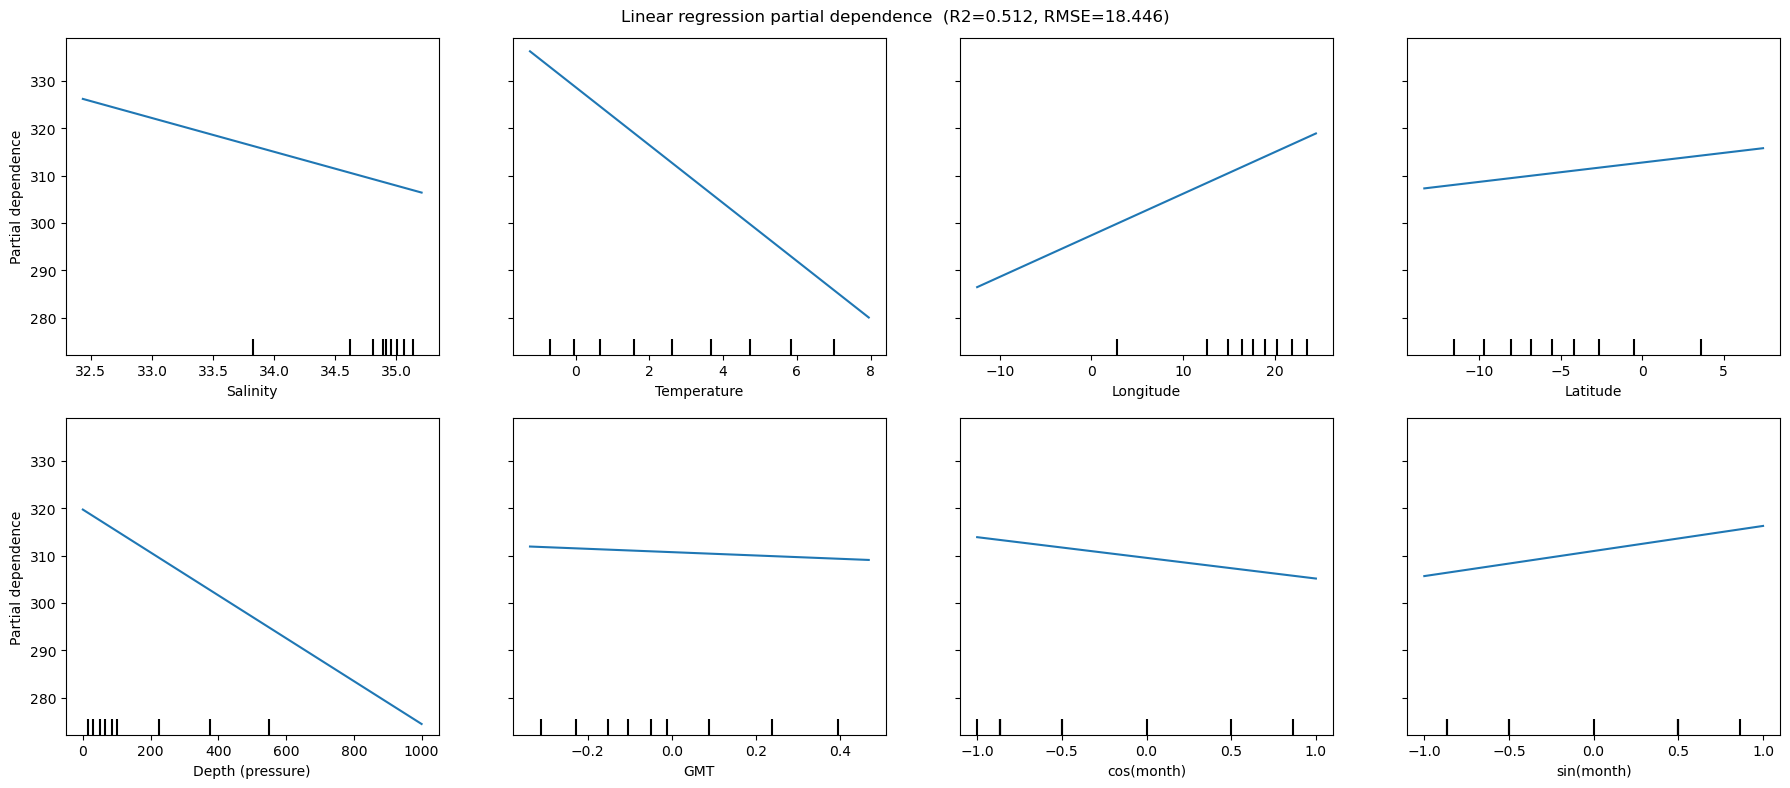

In [140]:
from sklearn.inspection import PartialDependenceDisplay

# PD is estimated by averaging predictions over a background sample; a random
# subsample is enough here since the model is linear (the marginal slope doesn't
# depend on sample size) and keeps this fast on ~2.8M training rows
rng = np.random.default_rng(seed)
pd_idx = rng.choice(X_train_eda.shape[0], size=min(20000, X_train_eda.shape[0]), replace=False)

fig, ax = plt.subplots(figsize=(18, 8))
disp = PartialDependenceDisplay.from_estimator(
    lr_model, X_train_eda[pd_idx], features=range(len(feature_names)),
    feature_names=feature_names, n_cols=4, ax=ax,
)
disp.figure_.suptitle(f'Linear regression partial dependence  (R2={R2_lr:.3f}, RMSE={RMSE_lr:.3f})')
plt.tight_layout()
plt.savefig(f'Fig_EDA_LinearRegression_PartialDependence_v{ver}.pdf')
plt.show()

## PyTorch MLP model
- Plain fully-connected network: `Linear -> ReLU` per hidden layer, single linear output unit.
- `weight_decay` in the Adam optimizer plays the same role as sklearn's `alpha` (L2 regularization).
- Folds are trained **sequentially** on the single shared GPU — each fit already saturates the GPU internally, and running several fits concurrently via multiprocessing would just contend for the same device.

In [141]:
class MLP(nn.Module):
    def __init__(self, n_in, hidden_layer_sizes):
        super().__init__()
        layers = []
        n_prev = n_in
        for h in hidden_layer_sizes:
            layers.append(nn.Linear(n_prev, h))
            layers.append(nn.ReLU())
            n_prev = h
        layers.append(nn.Linear(n_prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def fit_mlp(X_tr, y_tr, hidden_layer_sizes, optim='SGD', weight_decay=0.01, \
            lr=1e-3, epochs=200, batch_size=4096, momentum = 0.9, nesterov = False, \
            betas=(0.9, 0.999), verbose=False, X_val=None, y_val=None, plot_live=False, \
            early_stopping=False, patience=20):
    # data is small enough to live on the GPU whole; mini-batching is done by
    # indexing GPU-resident tensors directly rather than via DataLoader, since
    # DataLoader's per-batch Python/host-transfer overhead dominates for a model
    # this small and makes the GPU no faster than plain CPU
    torch.manual_seed(seed)
    model = MLP(X_tr.shape[1], hidden_layer_sizes).to(device)
    if optim == 'SGD':
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, nesterov=nesterov, weight_decay=weight_decay)
    elif optim == 'Adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr, betas=betas, eps=1e-8, weight_decay=weight_decay)
    elif optim == 'AdamW':
        opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=betas, eps=1e-8, weight_decay=weight_decay)
    #
    loss_fn = nn.MSELoss()
    #
    X_t = torch.tensor(X_tr, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_tr, dtype=torch.float32, device=device)
    n = X_t.shape[0]
    #
    # X_val/y_val are optional: pass a held-out split to also track validation
    # loss each epoch (e.g. for the final retrain, using the outer test set)
    has_val = X_val is not None
    if has_val:
        X_v = torch.tensor(X_val, dtype=torch.float32, device=device)
        y_v = torch.tensor(y_val, dtype=torch.float32, device=device)
    #
    if early_stopping and not has_val:
        raise ValueError('early_stopping requires X_val/y_val to be provided')
    #
    train_losses = []
    val_losses = []
    # early stopping: track the best (lowest) validation loss seen so far and its
    # epoch/weights; once `patience` epochs pass with no improvement, stop and roll
    # the model back to those best weights rather than keeping the final (possibly
    # overfit) ones
    best_val_loss = np.inf
    best_epoch = None
    best_state = None
    epochs_no_improve = 0
    # plot_live requires has_val (nothing to plot against otherwise) and redraws
    # a single figure in place every 10 epochs, notebook-only (uses IPython display)
    if plot_live and has_val:
        fig, ax = plt.subplots(figsize=(6, 4))
    #
    model.train()
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            xb, yb = X_t[idx], y_t[idx]
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()*xb.size(0)
        train_losses.append(epoch_loss/n)
        # evaluate validation loss on the full held-out split (no mini-batching needed for eval)
        if has_val:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(X_v), y_v).item()
            val_losses.append(val_loss)
            if early_stopping:
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_epoch = epoch
                    best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
        if plot_live and has_val and ((epoch + 1) % 10 == 0 or epoch == epochs - 1):
            # display intermediate results
            clear_output(wait=True)
            ax.clear()
            ax.plot(np.arange(0, epoch+1, 1), train_losses, '-', color='b', label='Train')
            ax.plot(np.arange(0, epoch+1, 1), val_losses, '--', color='r', label='Valid')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Loss')
            ax.legend()
            display(fig)
            print(f'Epoch {epoch+1}/{epochs}  train loss={epoch_loss/n:.4f}')
        elif verbose and (epoch % 20 == 0 or epoch == epochs-1):
            msg = f'  epoch {epoch:4d}  train MSE = {epoch_loss/n:.5f}'
            if has_val:
                msg += f'  val MSE = {val_loss:.5f}'
            print(msg)
        if early_stopping and epochs_no_improve >= patience:
            if verbose:
                print(f'  early stopping at epoch {epoch+1} '
                      f'(best epoch {best_epoch+1}, best val MSE = {best_val_loss:.5f})')
            break
    if early_stopping and best_state is not None:
        model.load_state_dict(best_state)
    model.best_epoch = best_epoch
    if plot_live and has_val:
        plt.close(fig)
    model.train_losses = train_losses
    model.val_losses = val_losses
    return model


@torch.no_grad()
def predict_mlp(model, X):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    return model(X_t).cpu().numpy()

### Vanilla SGD as a baseline

In [ ]:
# single model training with all training data
#
model = fit_mlp(X_train, y_train, [64,64], optim='SGD', weight_decay = 0, lr=.1, \
                momentum = 0, nesterov=False, batch_size=100000, epochs=2000, verbose=True, X_val = X_test, y_val = y_test, \
                plot_live=True)
#model = fit_mlp(X_train, y_train, [64,64], optim='AdamW', weight_decay = 0.01, lr=0.01, \
#                betas=(0.9,0.999), batch_size=100000, epochs=1000, verbose=True, X_val = X_test, y_val = y_test, \
#                plot_live=True)
y_est = predict_mlp(model, X_test)
#
R2 = r2_score(y_test, y_est)
RMSE = np.sqrt(np.mean((y_est-y_test)**2))*ystd
print(f'R2={R2:.4f}  RMSE={RMSE:.4f}')
log_result('SGD', 'lr=0.1, mom=0, wd=0', R2, RMSE)

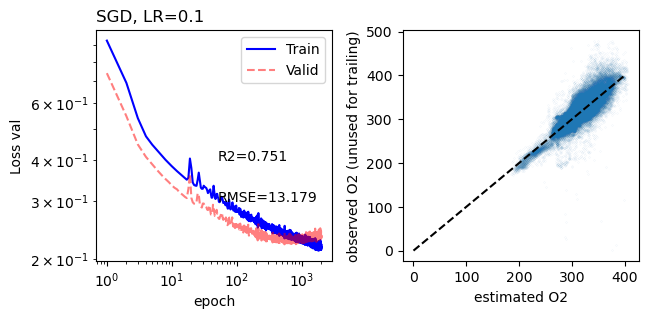

In [143]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
plt.subplots_adjust(wspace=.3)

ep=np.arange(1,len(model.train_losses)+1,1)
ax[0].loglog(ep,model.train_losses, '-', color='b', label='Train')
ax[0].loglog(ep,model.val_losses, '--', color='r', label='Valid',alpha=.5)
ax[0].text(50,.4,f'R2={R2:.3f}')
ax[0].text(50,.3,f'RMSE={RMSE:.3f}')
#plt.title('Vanilla SGD, LR=0.1, Momentum=0')
ax[0].set_title('SGD, LR=0.1',loc='left')
#plt.title('AdamW [64,32], LR=0.01, betas=(0.9, 0.999), wd=0.01')
ax[0].legend()
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Loss val')

ax[1].plot(y_est*ystd+ym,y_test*ystd+ym,'.',markersize=.1,alpha=.5)
ax[1].plot(np.arange(0,400,1),np.arange(0,400,1),'--',color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2 (unused for trailing)')
plt.savefig(f'Fig_SGD_baseline_v{ver}.pdf',bbox_inches='tight')

### SGD with Nesterov momentum = 0.9

In [ ]:
# single model training with all training data
#
model = fit_mlp(X_train, y_train, [64,64], optim='SGD', weight_decay = 0, lr=.1, \
                momentum = 0.9, nesterov=True, batch_size=100000, epochs=2000, verbose=True, X_val = X_test, y_val = y_test, \
                plot_live=True)
#model = fit_mlp(X_train, y_train, [64,64], optim='AdamW', weight_decay = 0.01, lr=0.01, \
#                betas=(0.9,0.999), batch_size=100000, epochs=1000, verbose=True, X_val = X_test, y_val = y_test, \
#                plot_live=True)
y_est = predict_mlp(model, X_test)
#
R2 = r2_score(y_test, y_est)
RMSE = np.sqrt(np.mean((y_est-y_test)**2))*ystd
print(f'R2={R2:.4f}  RMSE={RMSE:.4f}')
log_result('SGD', 'lr=0.1, Nesterov mom=0.9, wd=0', R2, RMSE)

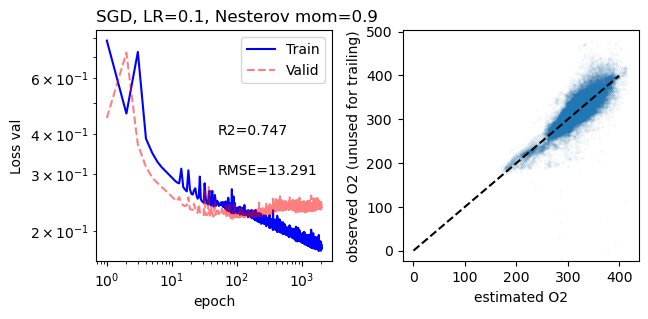

In [146]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
plt.subplots_adjust(wspace=.3)

ep=np.arange(1,len(model.train_losses)+1,1)
ax[0].loglog(ep,model.train_losses, '-', color='b', label='Train')
ax[0].loglog(ep,model.val_losses, '--', color='r', label='Valid',alpha=.5)
ax[0].text(50,.4,f'R2={R2:.3f}')
ax[0].text(50,.3,f'RMSE={RMSE:.3f}')
#plt.title('Vanilla SGD, LR=0.1, Momentum=0')
ax[0].set_title('SGD, LR=0.1, Nesterov mom=0.9',loc='left')
#plt.title('AdamW [64,32], LR=0.01, betas=(0.9, 0.999), wd=0.01')
ax[0].legend()
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Loss val')

ax[1].plot(y_est*ystd+ym,y_test*ystd+ym,'.',markersize=.1,alpha=.5)
ax[1].plot(np.arange(0,400,1),np.arange(0,400,1),'--',color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2 (unused for trailing)')

plt.savefig(f'Fig_SGD_Nesterov_v{ver}.pdf',bbox_inches='tight')

# Adam optimizer

In [ ]:
# single model training with all training data
#
#model = fit_mlp(X_train, y_train, [64,64], optim='SGD', weight_decay = 0, lr=.1, \
#                momentum = 0.9, nesterov=True, batch_size=100000, epochs=2000, verbose=True, X_val = X_test, y_val = y_test, \
#                plot_live=True)
model = fit_mlp(X_train, y_train, [64,64], optim='Adam', weight_decay = 0, lr=0.01, \
                betas=(0.9,0.999), batch_size=100000, epochs=500, verbose=True, X_val = X_test, y_val = y_test, \
                plot_live=True)
y_est = predict_mlp(model, X_test)
#
R2 = r2_score(y_test, y_est)
RMSE = np.sqrt(np.mean((y_est-y_test)**2))*ystd
print(f'R2={R2:.4f}  RMSE={RMSE:.4f}')
log_result('Adam', 'lr=0.01, wd=0', R2, RMSE)

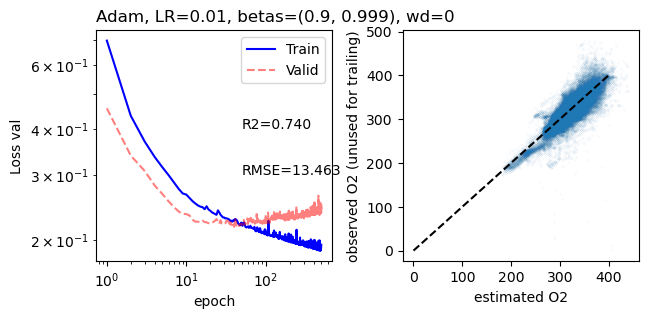

In [148]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
plt.subplots_adjust(wspace=.3)

ep=np.arange(1,len(model.train_losses)+1,1)
ax[0].loglog(ep,model.train_losses, '-', color='b', label='Train')
ax[0].loglog(ep,model.val_losses, '--', color='r', label='Valid',alpha=.5)
ax[0].text(50,.4,f'R2={R2:.3f}')
ax[0].text(50,.3,f'RMSE={RMSE:.3f}')
#plt.title('Vanilla SGD, LR=0.1, Momentum=0')
ax[0].set_title('Adam, LR=0.01, betas=(0.9, 0.999), wd=0',loc='left')
#plt.title('AdamW [64,32], LR=0.01, betas=(0.9, 0.999), wd=0.01')
ax[0].legend()
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Loss val')

ax[1].plot(y_est*ystd+ym,y_test*ystd+ym,'.',markersize=.1,alpha=.5)
ax[1].plot(np.arange(0,400,1),np.arange(0,400,1),'--',color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2 (unused for trailing)')

plt.savefig(f'Fig_Adam_baseline_v{ver}.pdf',bbox_inches='tight')

### Adam with early stopping (patience=50)
- Same configuration as the Adam run above, but training stops once validation loss hasn't improved for 50 consecutive epochs, and the returned model's weights are rolled back to the best (lowest validation-loss) epoch rather than the final one.
- Useful for the Southern Ocean case (`ver='2.3.4.4.6.4'`), where the run above shows signs of overfitting (validation loss rising while training loss keeps falling).

In [ ]:
# single model training with all training data, with early stopping (patience=50)
#
model = fit_mlp(X_train, y_train, [64,64], optim='Adam', weight_decay = 0, lr=0.01, \
                betas=(0.9,0.999), batch_size=100000, epochs=500, verbose=True, X_val = X_test, y_val = y_test, \
                plot_live=True, early_stopping=True, patience=50)
y_est = predict_mlp(model, X_test)
#
R2 = r2_score(y_test, y_est)
RMSE = np.sqrt(np.mean((y_est-y_test)**2))*ystd
print(f'R2={R2:.4f}  RMSE={RMSE:.4f}')
if model.best_epoch is not None:
    print(f'Best epoch (restored): {model.best_epoch+1} of {len(model.val_losses)} run')
log_result('Adam (early stop, patience=50)', 'lr=0.01, wd=0', R2, RMSE)

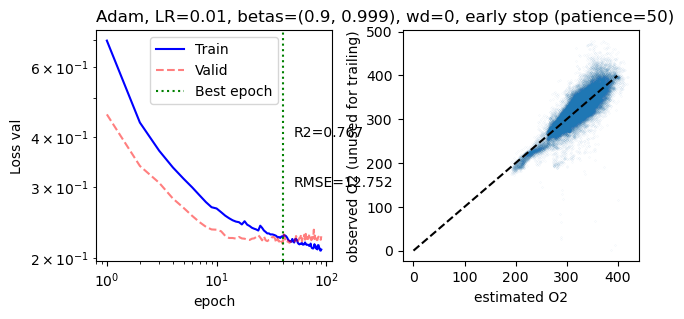

In [150]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
plt.subplots_adjust(wspace=.3)

ep=np.arange(1,len(model.train_losses)+1,1)
ax[0].loglog(ep,model.train_losses, '-', color='b', label='Train')
ax[0].loglog(ep,model.val_losses, '--', color='r', label='Valid',alpha=.5)
if model.best_epoch is not None:
    ax[0].axvline(model.best_epoch+1, color='g', linestyle=':', label='Best epoch')
ax[0].text(50,.4,f'R2={R2:.3f}')
ax[0].text(50,.3,f'RMSE={RMSE:.3f}')
ax[0].set_title('Adam, LR=0.01, betas=(0.9, 0.999), wd=0, early stop (patience=50)',loc='left')
ax[0].legend()
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Loss val')

ax[1].plot(y_est*ystd+ym,y_test*ystd+ym,'.',markersize=.1,alpha=.5)
ax[1].plot(np.arange(0,400,1),np.arange(0,400,1),'--',color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2 (unused for trailing)')

plt.savefig(f'Fig_Adam_earlystop_v{ver}.pdf',bbox_inches='tight')

## AdamW

In [ ]:
# single model training with all training data
#
#model = fit_mlp(X_train, y_train, [64,64], optim='SGD', weight_decay = 0, lr=.1, \
#                momentum = 0.9, nesterov=True, batch_size=100000, epochs=2000, verbose=True, X_val = X_test, y_val = y_test, \
#                plot_live=True)
model = fit_mlp(X_train, y_train, [64,64], optim='AdamW', weight_decay = 0.1, lr=0.01, \
                betas=(0.9,0.999), batch_size=100000, epochs=500, verbose=True, X_val = X_test, y_val = y_test, \
                plot_live=True)
y_est = predict_mlp(model, X_test)
#
R2 = r2_score(y_test, y_est)
RMSE = np.sqrt(np.mean((y_est-y_test)**2))*ystd
print(f'R2={R2:.4f}  RMSE={RMSE:.4f}')
log_result('AdamW', 'lr=0.01, wd=0.1', R2, RMSE)

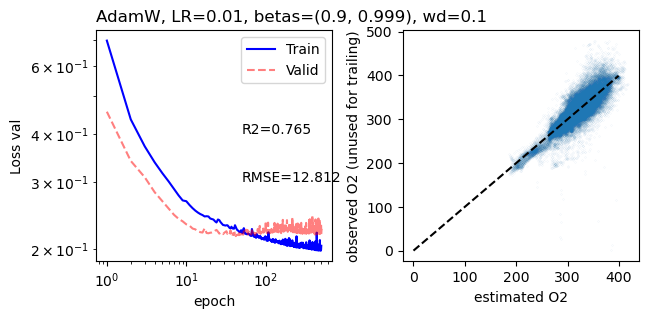

In [152]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
plt.subplots_adjust(wspace=.3)

ep=np.arange(1,len(model.train_losses)+1,1)
ax[0].loglog(ep,model.train_losses, '-', color='b', label='Train')
ax[0].loglog(ep,model.val_losses, '--', color='r', label='Valid',alpha=.5)
ax[0].text(50,.4,f'R2={R2:.3f}')
ax[0].text(50,.3,f'RMSE={RMSE:.3f}')
#plt.title('Vanilla SGD, LR=0.1, Momentum=0')
ax[0].set_title('AdamW, LR=0.01, betas=(0.9, 0.999), wd=0.1',loc='left')
#plt.title('AdamW [64,32], LR=0.01, betas=(0.9, 0.999), wd=0.01')
ax[0].legend()
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Loss val')

ax[1].plot(y_est*ystd+ym,y_test*ystd+ym,'.',markersize=.1,alpha=.5)
ax[1].plot(np.arange(0,400,1),np.arange(0,400,1),'--',color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2 (unused for trailing)')

plt.savefig(f'Fig_AdamW_baseline_v{ver}.pdf',bbox_inches='tight')

### AdamW with early stopping (patience=50)
- Same configuration as the AdamW run above, but training stops once validation loss hasn't improved for 50 consecutive epochs, and the returned model's weights are rolled back to the best (lowest validation-loss) epoch rather than the final one.

In [ ]:
# single model training with all training data, with early stopping (patience=50)
#
model = fit_mlp(X_train, y_train, [64,64], optim='AdamW', weight_decay = 0.1, lr=0.01, \
                betas=(0.9,0.999), batch_size=100000, epochs=500, verbose=True, X_val = X_test, y_val = y_test, \
                plot_live=True, early_stopping=True, patience=50)
y_est = predict_mlp(model, X_test)
#
R2 = r2_score(y_test, y_est)
RMSE = np.sqrt(np.mean((y_est-y_test)**2))*ystd
print(f'R2={R2:.4f}  RMSE={RMSE:.4f}')
if model.best_epoch is not None:
    print(f'Best epoch (restored): {model.best_epoch+1} of {len(model.val_losses)} run')
log_result('AdamW (early stop, patience=50)', 'lr=0.01, wd=0.1', R2, RMSE)

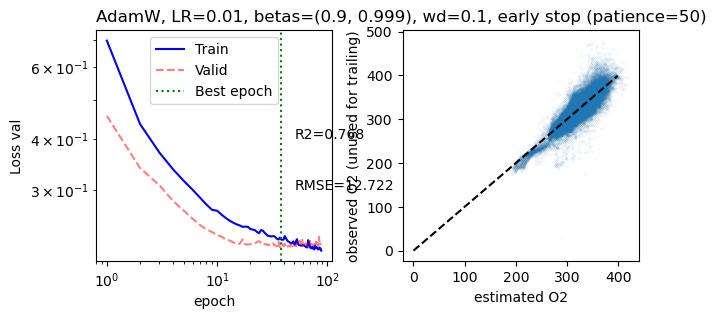

In [154]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
plt.subplots_adjust(wspace=.3)

ep=np.arange(1,len(model.train_losses)+1,1)
ax[0].loglog(ep,model.train_losses, '-', color='b', label='Train')
ax[0].loglog(ep,model.val_losses, '--', color='r', label='Valid',alpha=.5)
if model.best_epoch is not None:
    ax[0].axvline(model.best_epoch+1, color='g', linestyle=':', label='Best epoch')
ax[0].text(50,.4,f'R2={R2:.3f}')
ax[0].text(50,.3,f'RMSE={RMSE:.3f}')
ax[0].set_title('AdamW, LR=0.01, betas=(0.9, 0.999), wd=0.1, early stop (patience=50)',loc='left')
ax[0].legend()
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Loss val')

ax[1].plot(y_est*ystd+ym,y_test*ystd+ym,'.',markersize=.1,alpha=.5)
ax[1].plot(np.arange(0,400,1),np.arange(0,400,1),'--',color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2 (unused for trailing)')

plt.savefig(f'Fig_AdamW_earlystop_v{ver}.pdf',bbox_inches='tight')

## Sensitivity study: is the model just learning climatology?
- Concern: lon/lat/depth/season alone already define a strong climatological prior for dissolved O2, so high skill could come mostly from those coordinates rather than from the time-evolving ocean state — which would mean the model isn't really capturing interannual/decadal dynamics.
- GMT (global mean temperature) evolves over time, so leaving it in the "climatology-only" set would let time-evolving information leak back in through the back door. This version drops Salinity, Temperature, **and GMT**, keeping only lon, lat, depth, cos/sin(month) — a truly static climatology with no time-varying information at all.
- Refit both the linear regression baseline and an MLP (same architecture/optimizer as the Adam run above) on the same train/test split, and compare against the full-feature results.
- If R2 barely drops, the full model is mostly reproducing a static climatology; a large drop indicates the time-evolving predictors (T, S, GMT) carry real predictive information beyond position and season.

In [155]:
# build the pure-climatology (no T/S/GMT) feature set, in both the standardized
# form used by the MLP and the raw-unit form used by the linear regression
clim_idx = [i for i, n in enumerate(feature_names) if n not in ('Salinity', 'Temperature', 'GMT')]
feature_names_clim = [feature_names[i] for i in clim_idx]
print('Climatology-only features:', feature_names_clim)

X_train_clim = X_train[:, clim_idx]
X_test_clim = X_test[:, clim_idx]

X_train_eda_clim = X_train_eda[:, clim_idx]
X_test_lr_clim = X_test_lr[:, clim_idx]

Climatology-only features: ['Longitude', 'Latitude', 'Depth (pressure)', 'cos(month)', 'sin(month)']


In [ ]:
lr_model_clim = LinearRegression()
lr_model_clim.fit(X_train_eda_clim, y_train_eda)

y_est_lr_clim = lr_model_clim.predict(X_test_lr_clim)
R2_lr_clim = r2_score(y_test_lr, y_est_lr_clim)
RMSE_lr_clim = np.sqrt(np.mean((y_est_lr_clim - y_test_lr)**2))

print(f'Linear Regression, full features   : R2={R2_lr:.4f}  RMSE={RMSE_lr:.4f}')
print(f'Linear Regression, no T/S/GMT       : R2={R2_lr_clim:.4f}  RMSE={RMSE_lr_clim:.4f}')
log_result('Linear Regression', 'no T/S/GMT (climatology only)', R2_lr_clim, RMSE_lr_clim)

In [ ]:
# refit the MLP from scratch on both feature sets with identical hyperparameters
# (same Adam config as the "Adam optimizer" section above) for a clean, apples-to-apples
# comparison, rather than relying on the R2/RMSE/model globals left over from earlier cells
mlp_kwargs = dict(hidden_layer_sizes=[64, 64], optim='Adam', weight_decay=0, lr=0.01, \
                   betas=(0.9, 0.999), batch_size=100000, epochs=500, verbose=True, \
                    early_stopping=True, patience=50)

print('--- full features (T, S, GMT included) ---')
model_full = fit_mlp(X_train, y_train, X_val=X_test, y_val=y_test, **mlp_kwargs)
y_est_full = predict_mlp(model_full, X_test)
R2_mlp_full = r2_score(y_test, y_est_full)
RMSE_mlp_full = np.sqrt(np.mean((y_est_full - y_test)**2))*ystd
print(f'MLP (Adam), full features : R2={R2_mlp_full:.4f}  RMSE={RMSE_mlp_full:.4f}')

print('--- climatology-only features (no T/S/GMT) ---')
model_clim = fit_mlp(X_train_clim, y_train, X_val=X_test_clim, y_val=y_test, **mlp_kwargs)
y_est_clim = predict_mlp(model_clim, X_test_clim)
R2_mlp_clim = r2_score(y_test, y_est_clim)
RMSE_mlp_clim = np.sqrt(np.mean((y_est_clim - y_test)**2))*ystd
print(f'MLP (Adam), no T/S/GMT    : R2={R2_mlp_clim:.4f}  RMSE={RMSE_mlp_clim:.4f}')
log_result('MLP (Adam, early stop patience=50)', 'full features (sensitivity refit)', R2_mlp_full, RMSE_mlp_full)
log_result('MLP (Adam, early stop patience=50)', 'no T/S/GMT (climatology only)', R2_mlp_clim, RMSE_mlp_clim)

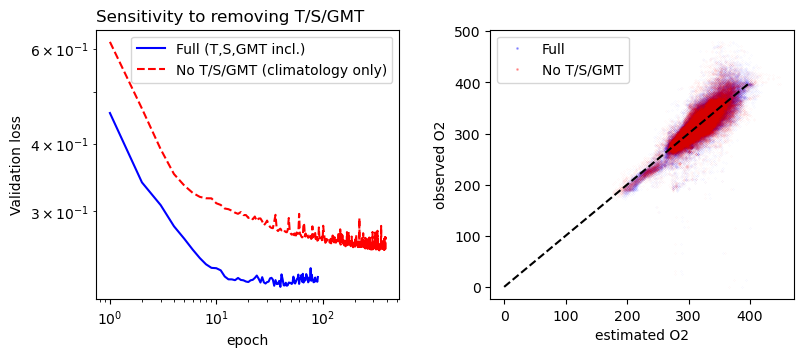

In [158]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
plt.subplots_adjust(wspace=.3)

ep = np.arange(1, len(model_full.val_losses)+1)
ax[0].loglog(ep, model_full.val_losses, '-', color='b', label='Full (T,S,GMT incl.)')
ep = np.arange(1, len(model_clim.val_losses)+1)
ax[0].loglog(ep, model_clim.val_losses, '--', color='r', label='No T/S/GMT (climatology only)')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Validation loss')
ax[0].set_title('Sensitivity to removing T/S/GMT', loc='left')
ax[0].legend()

ax[1].plot(y_est_full*ystd+ym, y_test*ystd+ym, '.', markersize=.1, alpha=.3, color='b', label='Full')
ax[1].plot(y_est_clim*ystd+ym, y_test*ystd+ym, '.', markersize=.1, alpha=.3, color='r', label='No T/S/GMT')
ax[1].plot(np.arange(0, 400, 1), np.arange(0, 400, 1), '--', color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2')
ax[1].legend(markerscale=20)

plt.savefig(f'Fig_sensitivity_noTSGMT_v{ver}.pdf', bbox_inches='tight')
plt.show()

In [159]:
summary = pd.DataFrame({
    'model': ['Linear Regression', 'Linear Regression', 'MLP (Adam)', 'MLP (Adam)'],
    'features': ['full (T,S,GMT incl.)', 'no T/S/GMT (pure climatology)', 'full (T,S,GMT incl.)', 'no T/S/GMT (pure climatology)'],
    'R2': [R2_lr, R2_lr_clim, R2_mlp_full, R2_mlp_clim],
    'RMSE': [RMSE_lr, RMSE_lr_clim, RMSE_mlp_full, RMSE_mlp_clim],
})
display(summary)

,model,features,R2,RMSE
0,Linear Regression,"full (T,S,GMT incl.)",0.511819,18.446486
1,Linear Regression,no T/S/GMT (pure climatology),0.162397,24.162513
2,MLP (Adam),"full (T,S,GMT incl.)",0.766720,12.751511
3,MLP (Adam),no T/S/GMT (pure climatology),0.727315,13.786485


## Station case study: does the MLP capture climatology vs anomalies?
- Applies the two already-trained basin-wide models (`model_full`: T,S,GMT,lon,lat,depth,season; `model_clim`: lon,lat,depth,season only) to each station identified above (BATS for the Atlantic; HOT and OSP for the Pacific) at the same 4 depth bins used in the raw time series above, over the full time record (train+test years combined). Basins with no station definition (see the station-identification cell) produce no plots here.
- `model_clim`'s prediction is the model's climatology (repeating seasonal cycle, no interannual variation by construction). The gap between `model_full` and `model_clim` is the model's anomaly correction from T/S/GMT; comparing both against the observed series shows whether that correction actually tracks real interannual/decadal variability at each station or just adds noise.

In [124]:
# predict with both models over the full train+test split, then combine per depth bin
# into a single time-ordered series for each station (mirrors the raw time-series cell above)
depth_train_full = depth_z[ind1]
depth_test_full = depth_z[ind]

y_est_full_train = predict_mlp(model_full, X_train)
y_est_full_test = predict_mlp(model_full, X_test)
y_est_clim_train = predict_mlp(model_clim, X_train_clim)
y_est_clim_test = predict_mlp(model_clim, X_test_clim)

# kept for the low-pass filtering analysis below, so it doesn't need to
# recompute the per-depth-bin monthly series from scratch
station_ts_by_depth = {}

for name, st in stations.items():
    ts_by_depth = []
    fig, axes = plt.subplots(len(depth_bins), 1, figsize=(7, 8), sharex=True)
    for row, (dmin, dmax) in enumerate(depth_bins):
        m_tr = st['train'] & (depth_train_full >= dmin) & (depth_train_full < dmax)
        m_te = st['test'] & (depth_test_full >= dmin) & (depth_test_full < dmax)

        t = np.concatenate([tt1z[ind1][m_tr], tt1z[ind][m_te]])
        obs = np.concatenate([y_train[m_tr], y_test[m_te]]) * ystd + ym
        pred_full = np.concatenate([y_est_full_train[m_tr], y_est_full_test[m_te]]) * ystd + ym
        pred_clim = np.concatenate([y_est_clim_train[m_tr], y_est_clim_test[m_te]]) * ystd + ym

        ts = pd.DataFrame({'t': t, 'obs': obs, 'pred_full': pred_full, 'pred_clim': pred_clim}) \
               .groupby('t').mean().reset_index()
        ts_by_depth.append(ts)
        year = ts['t']/12 + 1965

        # Pearson r between the observed and each predicted series (pandas .corr is
        # pairwise-complete, so any NaNs would be dropped rather than propagating,
        # though none are expected here since ts is grouped over real timestamps)
        r_full = ts['obs'].corr(ts['pred_full'])
        r_clim = ts['obs'].corr(ts['pred_clim'])

        ax = axes[row]
        ax.plot(year, ts['obs'], '.', color='k', markersize=4, label='Observed')
        ax.plot(year, ts['pred_full'], '-', color='b', linewidth=1, label='MLP full (T,S,GMT)')
        ax.plot(year, ts['pred_clim'], '-', color='r', linewidth=1, alpha=.7, label='MLP climatology-only')
        ax.set_title(f'{name}: {dmin}-{dmax} m', loc='left')
        ax.set_ylabel('O2')
        ax.text(0.02, 0.95, f'r(full)={r_full:.2f}  r(clim)={r_clim:.2f}',
                transform=ax.transAxes, fontsize=7, va='top')
        if row == 0:
            ax.legend(fontsize=8)
    axes[-1].set_xlabel('Year')
    plt.tight_layout()
    plt.savefig(f'Fig_{name}_MLP_climatology_anomaly_v{ver}.pdf')
    plt.show()

    station_ts_by_depth[name] = ts_by_depth

### Low-pass filtered station time series (seasonal cycle removed)
- Reuses the monthly-binned observed/predicted series computed above (`station_ts_by_depth`), one per station, one per depth bin within each.
- Each series is reindexed onto a continuous monthly grid (missing months filled with NaN) so the filter window spans real calendar months rather than just months with data.
- A 13-month centered rolling mean (`min_periods=9`) is the low-pass filter: it averages over slightly more than one full annual cycle, which suppresses the seasonal cycle and any shorter-period variability while passing interannual/decadal variability.
- `pred_clim`'s filtered curve is a null baseline: since `model_clim` only sees lon/lat/depth/season, its filtered prediction should stay essentially flat, showing how much residual seasonal leakage smoothing alone removes. `pred_full`'s filtered curve tracks `obs` only if T/S/GMT carry real low-frequency O2 signal beyond climatology.

In [106]:
# low-pass filter (13-month centered rolling mean) applied to each depth bin's
# monthly series, to isolate interannual/decadal variability from the seasonal cycle
LOWPASS_WINDOW = 13
LOWPASS_MIN_PERIODS = 9

for name, ts_by_depth in station_ts_by_depth.items():
    fig, axes = plt.subplots(len(depth_bins), 1, figsize=(7, 8), sharex=True)
    for row, ((dmin, dmax), ts) in enumerate(zip(depth_bins, ts_by_depth)):
        t_full = np.arange(ts['t'].min(), ts['t'].max() + 1)
        ts_full = ts.set_index('t').reindex(t_full)
        ts_lp = ts_full.rolling(window=LOWPASS_WINDOW, center=True, min_periods=LOWPASS_MIN_PERIODS).mean()
        year = t_full/12 + 1965

        # Pearson r on the low-pass series (pandas .corr is pairwise-complete over
        # non-NaN rows, since the rolling mean leaves NaN at the ends / any data gaps)
        r_full = ts_lp['obs'].corr(ts_lp['pred_full'])
        r_clim = ts_lp['obs'].corr(ts_lp['pred_clim'])

        ax = axes[row]
        ax.plot(year, ts_lp['obs'], '-', color='k', linewidth=1.2, label='Observed')
        ax.plot(year, ts_lp['pred_full'], '-', color='b', linewidth=1.2, label='MLP full (T,S,GMT)')
        ax.plot(year, ts_lp['pred_clim'], '-', color='r', linewidth=1.2, alpha=.7, label='MLP climatology-only')
        ax.set_title(f'{name}: {dmin}-{dmax} m', loc='left')
        ax.set_ylabel('O2 (13-mo low-pass)')
        ax.text(0.02, 0.95, f'r(full)={r_full:.2f}  r(clim)={r_clim:.2f}',
                transform=ax.transAxes, fontsize=7, va='top')
        if row == 0:
            ax.legend(fontsize=8)
    axes[-1].set_xlabel('Year')
    plt.tight_layout()
    plt.savefig(f'Fig_{name}_MLP_lowpass_v{ver}.pdf')
    plt.show()

In [107]:
# Mean seasonal cycle (monthly climatology): observed vs the two MLP models, at each
# station, restricted to the 0-50 m bin (surface waters, where the seasonal cycle is
# most cleanly resolved -- the deeper bins add little here and just clutter the figure).
# month0 (tc1) is 0-11 (0=Jan); shown as calendar month 1-12.
month_train_full = tc1[z_mask][ind1]
month_test_full = tc1[z_mask][ind]

dmin, dmax = 0, 50

if stations:
    fig, axes = plt.subplots(1, len(stations), figsize=(4*len(stations), 3.5), sharey=False, squeeze=False)
    axes = axes[0]
    for col, (name, st) in enumerate(stations.items()):
        m_tr = st['train'] & (depth_train_full >= dmin) & (depth_train_full < dmax)
        m_te = st['test'] & (depth_test_full >= dmin) & (depth_test_full < dmax)

        month = np.concatenate([month_train_full[m_tr], month_test_full[m_te]]) + 1
        obs = np.concatenate([y_train[m_tr], y_test[m_te]]) * ystd + ym
        pred_full = np.concatenate([y_est_full_train[m_tr], y_est_full_test[m_te]]) * ystd + ym
        pred_clim = np.concatenate([y_est_clim_train[m_tr], y_est_clim_test[m_te]]) * ystd + ym

        clim = pd.DataFrame({'month': month, 'obs': obs, 'pred_full': pred_full, 'pred_clim': pred_clim}) \
                 .groupby('month').mean().reset_index()

        ax = axes[col]
        ax.plot(clim['month'], clim['obs'], 'o-', color='k', label='Observed')
        ax.plot(clim['month'], clim['pred_full'], 's-', color='b', label='MLP full')
        ax.plot(clim['month'], clim['pred_clim'], '^-', color='r', label='MLP climatology-only')
        ax.set_title(f'{name}: {dmin}-{dmax} m', loc='left')
        ax.set_xlabel('Month')
        ax.set_xticks(range(1, 13))
        if col == 0:
            ax.set_ylabel('O2')
            ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'Fig_seasonal_climatology_v{ver}.pdf')
    plt.show()
else:
    print('No stations defined for this basin; skipping seasonal climatology plot.')

No stations defined for this basin; skipping seasonal climatology plot.


In [ ]:
# combined results table for this basin/ver -- SGD/Adam/AdamW baselines and
# their early-stopped variants, the linear-regression baseline, and the
# climatology-sensitivity refits (full vs. no-T/S/GMT features)
df_results = pd.DataFrame(results)
display(df_results)
df_results.to_csv(f'Results_v{ver}.csv', index=False)